In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [7]:
# Initialize the VADER Sentiment Analyzer
analyzer = SentimentIntensityAnalyzer()

In [8]:
# ----------- DEFINE HEADLINES AND RAW DATA ------------
print("Simulating financial news feed ....")
# Mock dataset mapping dates to financial headlines or social media chatter
news_feed = [
    {"date":"2026-07-01", "headline":"Apple AAPL stock surges as new AI chip shatters sales expectations!"},
    {"date":"2026-07-01", "headline":"Retail investors are buying the dip on AAPL today, massive momentum."},
    {"date":"2026-07-02", "headline":"EU regulators launch new antitrust probe into Apple App Store policies."},
    {"date":"2026-07-02", "headline":"AAPl shares dropping after analyst downgrades stock over supply chain degrades."},
    {"date":"2026-07-03", "headline":"Rumours:Apple working on a revolutionary new smart glass hardware."},
    {"date":"2026-07-03", "headline":"Market correction hits tech sector but AAPL holds relatively steady."},
    {"date":"2026-07-04", "headline":"Apple beats earning expectations, revenue up 12% year-over-year!"},
    {"date":"2026-07-04", "headline":"CEO expresses massive confidence in upcoming hardware pipeline during call."},
    {"date":"2026-07-05", "headline":"Major factory fire in Asia could disrupt holiday iPhone shipments."},
    {"date":"2026-07-05", "headline":"Investors panic slightly as AAPL supply vulnerability hits headlines."}
]
df_news = pd.DataFrame(news_feed)

Simulating financial news feed ....


In [9]:
# --------- RUN SENTIMENT ANALYSIS (NLP) ----------
print("Analyzing sentiment with VADER ....")
# VADER returns a compound score between -1 to +1 
def get_sentiment_score(text):
    scores = analyzer.polarity_scores(text)
    return scores['compound']
df_news['sentiment_score'] = df_news['headline'].apply(get_sentiment_score)
# Group headlines by date to calculate Average Daily Sentiment
daily_sentiment = df_news.groupby('date')['sentiment_score'].mean().reset_index()
print("\n--- Daily Aggregated Sentiment ---")
print(daily_sentiment)

Analyzing sentiment with VADER ....

--- Daily Aggregated Sentiment ---
         date  sentiment_score
0  2026-07-01          0.00000
1  2026-07-02         -0.11315
2  2026-07-03          0.20095
3  2026-07-04          0.25530
4  2026-07-05         -0.31565


In [10]:
# --------- CORRELATE WITH STOCK PRICES ---------
print("\nMapping sentiment to stock performance ....")
# Let's align this with a mock AAPL stock closing price sequence
# (We structure prices to loosely mirror the direction of the news)
stock_prices = {
    "date":['2026-07-01','2026-07-02','2026-07-03','2026-07-04','2026-07-05'],
    "close_price":[185.50,181.20,182.00,189.90,184.10]
}
df_prices = pd.DataFrame(stock_prices)
# Merge our sentiment metrics and price data tables cleanly on the date
merged_df = pd.merge(daily_sentiment, df_prices, on="date")


Mapping sentiment to stock performance ....


Generating Dual-Axis Comparison Charts ....


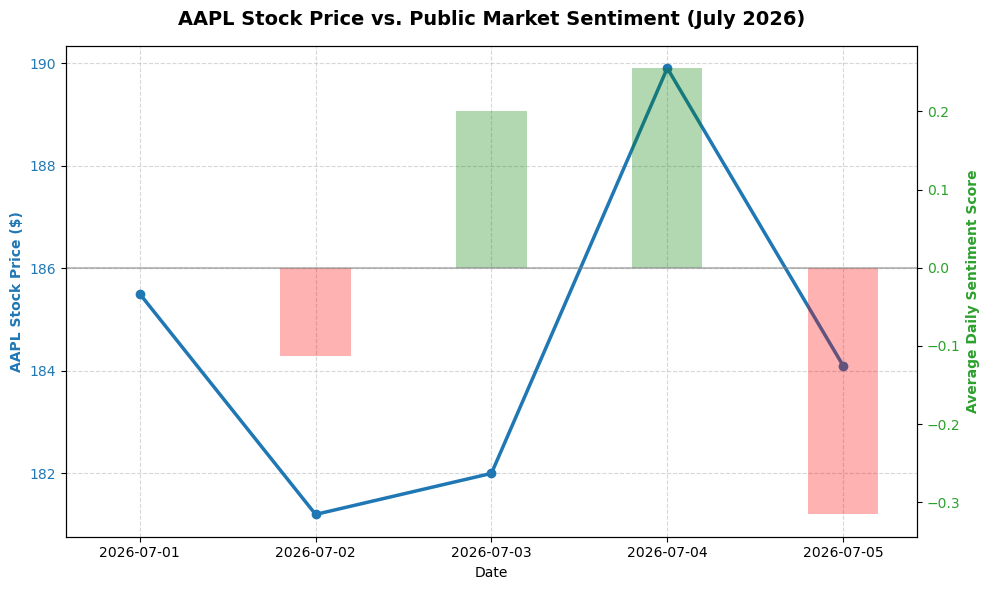

In [11]:
# ------- VISUALIZE SENTIMENT VS PRICE --------
print("Generating Dual-Axis Comparison Charts ....")
fig, ax1 = plt.subplots(figsize=(10,6))
# Plot the stock price as line chart on the primary Y-axis (left)
color = '#1f77b4'
ax1.set_xlabel('Date')
ax1.set_ylabel('AAPL Stock Price ($)', color=color, fontweight='bold')
line = ax1.plot(merged_df['date'], merged_df['close_price'], color=color, marker='o', linewidth=2.5, label='Stock Price')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)
# Create a secondary Y-axis (right) sharing the same X-axis for sentiment
ax2 = ax1.twinx()
color = '#2ca02c'
ax2.set_ylabel('Average Daily Sentiment Score', color=color, fontweight='bold')
# Plot daily sentiment scores as Bar chart
# Conditional Coloring: Green for positive, Red for negative sentiment
bar_colors = ['green' if x>=0 else 'red' for x in merged_df['sentiment_score']]
bars = ax2.bar(merged_df['date'], merged_df['sentiment_score'], color=bar_colors, alpha=0.3, width=0.4, label='Net Sentiment')
ax2.tick_params(axis='y', labelcolor=color)
# Add a horizontal baseline indicator at 0 
ax2.axhline(0, color='gray', linestyle='-', alpha=0.5)
plt.title('AAPL Stock Price vs. Public Market Sentiment (July 2026)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()